In [10]:
import numpy as np

#Problem 1: Number of Wheat on a 2×2 Square Chess Board
n_squares = 4
small_board_list = [1]
for _ in range(n_squares - 1):
    small_board_list.append(2 * small_board_list[-1])
#print("Arrange wheat on a plate of 4 squares (list)：{}".format(small_board_list))


In [11]:
small_board_ndarray = np.array(small_board_list).reshape((2,2))
print("Arrange wheat on a plate of 4 squares (ndarray)：\n{}".format(small_board_ndarray))


Arrange wheat on a plate of 4 squares (ndarray)：
[[1 2]
 [4 8]]


In [ ]:
#[Problem 2] Expansion to n × m mass

In [17]:
def create_chessboard_loop(n,m):
    total_squares = n*m
    board_list =[1]
    for _ in range(total_squares -1):
        board_list.append(2*board_list[-1])
    board_ndarray = np.array(board_list, dtype=np.uint64).reshape(n,m)
    return board_ndarray

In [19]:
# Create an 8x8 chessboard
eight_by_eight_board = create_chessboard_loop(8,8)
print(f"Number of wheat on an 8x8 chessboard:\n{eight_by_eight_board}\n")

Number of wheat on an 8x8 chessboard:
[[                  1                   2                   4
                    8                  16                  32
                   64                 128]
 [                256                 512                1024
                 2048                4096                8192
                16384               32768]
 [              65536              131072              262144
               524288             1048576             2097152
              4194304             8388608]
 [           16777216            33554432            67108864
            134217728           268435456           536870912
           1073741824          2147483648]
 [         4294967296          8589934592         17179869184
          34359738368         68719476736        137438953472
         274877906944        549755813888]
 [      1099511627776       2199023255552       4398046511104
        8796093022208      17592186044416      35184372088832
   

In [ ]:
#[Problem 3] Total number of wheat

Total number of wheat on an 8x8 chessboard: 18446744073709551615

Average number of wheat per column:
[9.04252160e+15 1.80850432e+16 3.61700864e+16 7.23401728e+16
 1.44680346e+17 2.89360691e+17 5.78721383e+17 1.15744277e+18]



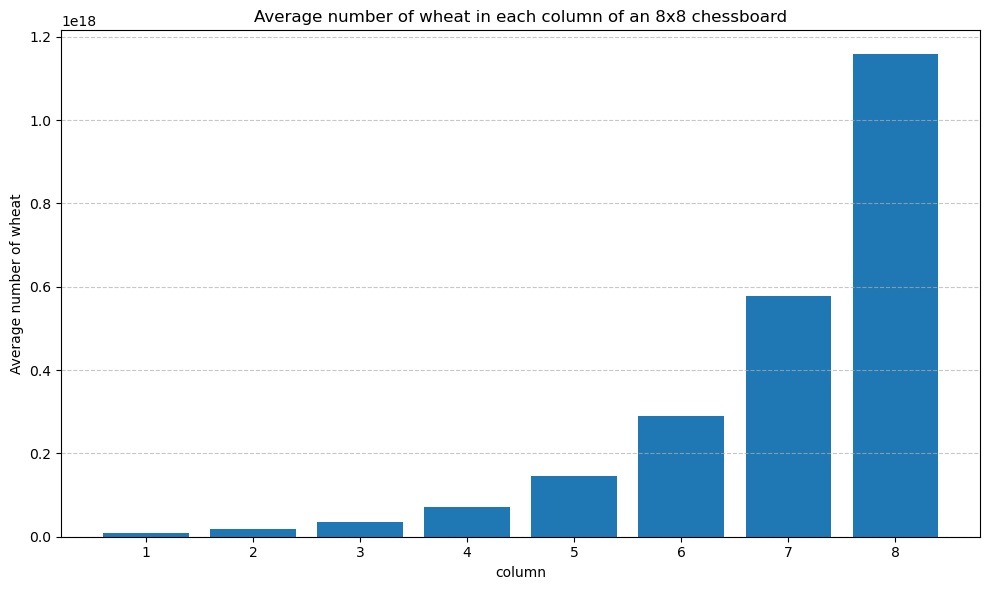

In [23]:
import matplotlib.pyplot as plt
%matplotlib inline

total_wheat = np.sum(eight_by_eight_board)
print(f"Total number of wheat on an 8x8 chessboard: {total_wheat}\n")

column_averages = np.mean(eight_by_eight_board, axis=0)
print(f"Average number of wheat per column:\n{column_averages}\n")
# Visualize the column averages using a bar chart
plt.figure(figsize=(10,6)) 
plt.xlabel("column")
plt.ylabel("Average number of wheat")
plt.title("Average number of wheat in each column of an 8x8 chessboard")
plt.bar(np.arange(1,9), column_averages) # from 1 to 8 (for columns), y-axis is the averages
plt.xticks(np.arange(1,9))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
#[Problem 4] Heat map of the number of wheat

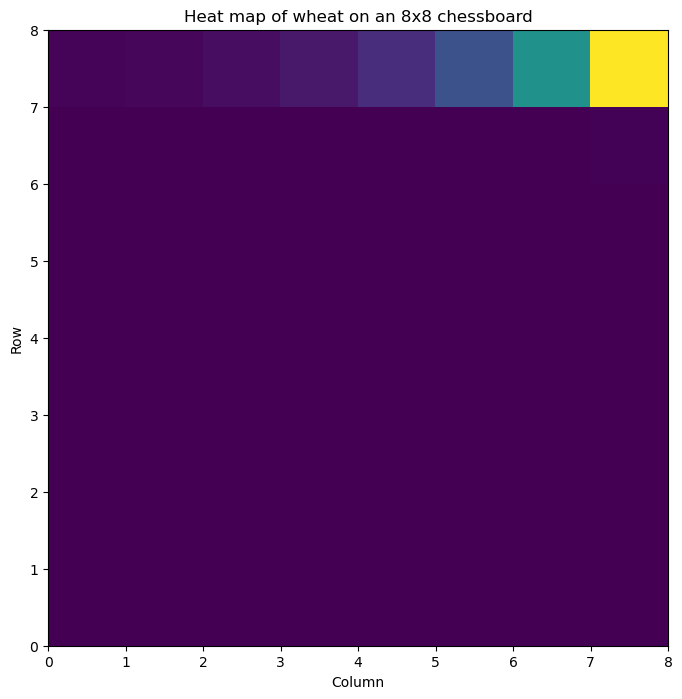

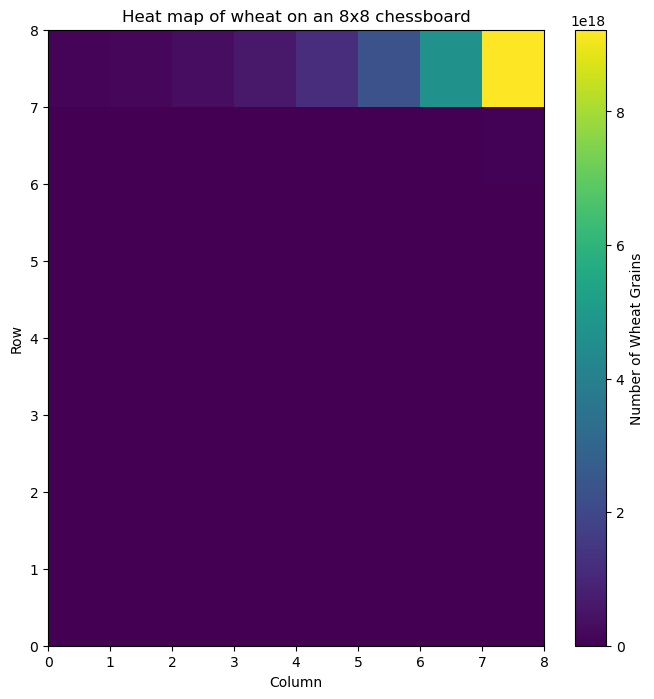

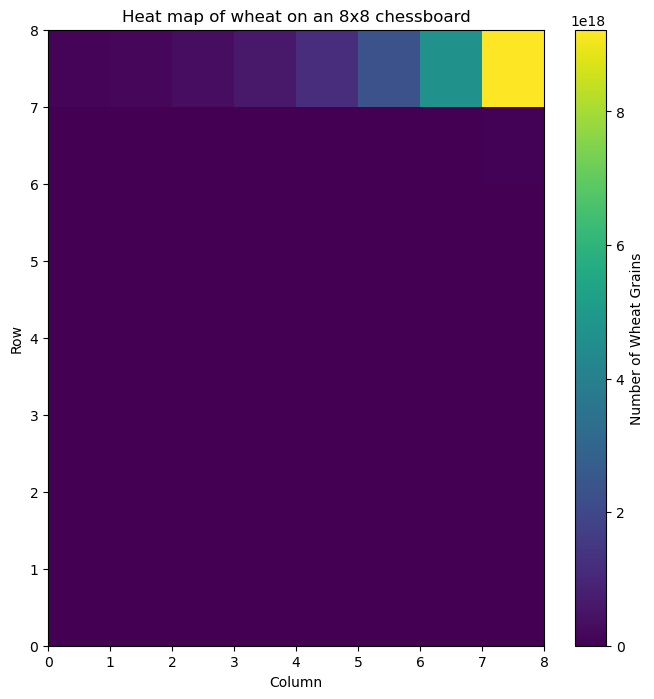

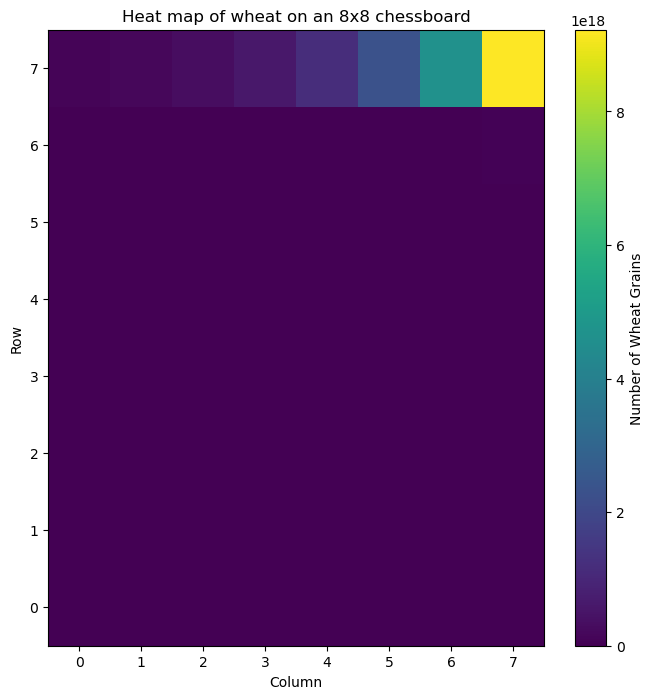

In [27]:
plt.figure(figsize=(8,8))
plt.xlabel("Column")
plt.ylabel("Row")
plt.title("Heat map of wheat on an 8x8 chessboard")
plt.pcolor(eight_by_eight_board,cmap='viridis')
plt.colorbar(label='Number of Wheat Grains')
plt.yticks(np.arange(0.5, 8.5), np.arange(0,8))
plt.xticks(np.arange(0.5, 8.5), np.arange(0,8))
plt.show()

In [ ]:
#[Problem 5] How many times is the second half as long as the first half?

In [28]:
first_half_rows = eight_by_eight_board[0:4, :] # rows 0 to 3, all columns
second_half_rows = eight_by_eight_board[4:8, :] # rows 4 to 7, all columns
# Calculate the sum of the first and second wheat grains
sum_first_half = np.sum(first_half_rows)
sum_second_half = np.sum(first_half_rows)
#Calculate the ratio
if sum_first_half !=0:
    ratio_second_to_first = sum_second_half / sum_first_half
    print(f"Sum of wheat in the first half of the chessboard: {sum_first_half}")
    print(f"Sum of wheat in the second half of the chessboard: {sum_second_half}")
    print(f"The second half has {ratio_second_to_first:.2f} times mmore wheat than the first half.\n")
else:
    print("The sum of wheat in the first half is zero, so the ratio cannot be calculated. \n")

Sum of wheat in the first half of the chessboard: 4294967295
Sum of wheat in the second half of the chessboard: 4294967295
The second half has 1.00 times mmore wheat than the first half.



In [ ]:
#[Problem 6] Expansion to n × m mass by another calculation method

In [30]:
def create_chessboard_np_append(n,m):
    total_squares =n*m
    small_board_ndarray = np.array([-1], dtype=np.uint64)
    for _ in range(total_squares -1):
        small_board_ndarray = np.append(small_board_ndarray, 2*small_board_ndarray[-1])
    return small_board_ndarray.reshape(n,m)
    
def create_chessboard_broadcast(n,m):
    total_squares = n*m
    indices_of_squares = np.arange(total_squares, dtype=np.uint64)
    # Use broadcasting
    board_ndarray = 2**indices_of_squares
    return board_ndarray.reshape(n,m)

#Use the function to create 8x8 boards and print them
eight_by_eight_append = create_chessboard_np_append(8,8)
print(f"8x8 chessboard using broadcast:\n {eight_by_eight_append}\n")

eight_by_eight_broadcast = create_chessboard_broadcast(8,8)
print(f"8x8 chessboard using broadcast:\n{eight_by_eight_broadcast}")

8x8 chessboard using broadcast:
 [[1.84467441e+19 3.68934881e+19 7.37869763e+19 1.47573953e+20
  2.95147905e+20 5.90295810e+20 1.18059162e+21 2.36118324e+21]
 [4.72236648e+21 9.44473297e+21 1.88894659e+22 3.77789319e+22
  7.55578637e+22 1.51115727e+23 3.02231455e+23 6.04462910e+23]
 [1.20892582e+24 2.41785164e+24 4.83570328e+24 9.67140656e+24
  1.93428131e+25 3.86856262e+25 7.73712525e+25 1.54742505e+26]
 [3.09485010e+26 6.18970020e+26 1.23794004e+27 2.47588008e+27
  4.95176016e+27 9.90352031e+27 1.98070406e+28 3.96140813e+28]
 [7.92281625e+28 1.58456325e+29 3.16912650e+29 6.33825300e+29
  1.26765060e+30 2.53530120e+30 5.07060240e+30 1.01412048e+31]
 [2.02824096e+31 4.05648192e+31 8.11296384e+31 1.62259277e+32
  3.24518554e+32 6.49037107e+32 1.29807421e+33 2.59614843e+33]
 [5.19229686e+33 1.03845937e+34 2.07691874e+34 4.15383749e+34
  8.30767497e+34 1.66153499e+35 3.32306999e+35 6.64613998e+35]
 [1.32922800e+36 2.65845599e+36 5.31691198e+36 1.06338240e+37
  2.12676479e+37 4.25352959e+3

C:\Users\lelin\AppData\Local\Temp\ipykernel_12524\1120271539.py:3: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of -1 to uint64 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  small_board_ndarray = np.array([-1], dtype=np.uint64)


In [ ]:
#[Problem 7] Comparing calculation times

In [33]:
%%timeit
import time
num_iterations = 1000
print("Measuring time for loop list/convert metod:")
start_time = time.perf_counter() # record the start time
for _ in range(num_iterations):
    create_chessboard_loop(8,8)
end_time = time.perf_counter()
avg_time_loop_list = (end_time -start_time)/ num_iterations
print(f"Average time for loop with list/convert method: {avg_time_loop_list:.6f} seconds")

# Measure time for the np.append() method (from Problem 6)
print("\nMeasuring time for np.append() method:")
start_time = time.perf_counter()
for _ in range(num_iterations):
    create_chessboard_np_append(8, 8) # Call the function repeatedly
end_time = time.perf_counter()
avg_time_np_append = (end_time - start_time) / num_iterations
print(f"Average time for np.append() method: {avg_time_np_append:.6f} seconds")


# Measure time for the broadcast method (from Problem 6)
print("\nMeasuring time for broadcast method:")
start_time = time.perf_counter()
for _ in range(num_iterations):
    create_chessboard_broadcast(8, 8) # Call the function repeatedly
end_time = time.perf_counter()
avg_time_broadcast = (end_time - start_time) / num_iterations
print(f"Average time for broadcast method: {avg_time_broadcast:.6f} seconds")

# Provide a comparison and consideration of the results
print("\nComparison and Consideration:")
print("The broadcast method is generally the most efficient due to NumPy's optimized C implementations, as it avoids explicit Python loops, leading to significantly faster execution times.")
print("The `np.append()` method is typically the slowest among these options, especially for larger arrays. This is because `np.append()` internally creates a new array and copies all existing data plus the new element in each iteration, which is an expensive operation.")
print("The loop with list/convert method performs reasonably well for moderate array sizes, but for very large datasets, NumPy's vectorized operations (like broadcasting) are always preferred for their speed and memory efficiency.")


Measuring time for loop list/convert metod:
Average time for loop with list/convert method: 0.000196 seconds

Measuring time for np.append() method:


C:\Users\lelin\AppData\Local\Temp\ipykernel_12524\1120271539.py:3: DeprecationWarning: NumPy will stop allowing conversion of out-of-bound Python integers to integer arrays.  The conversion of -1 to uint64 will fail in the future.
For the old behavior, usually:
    np.array(value).astype(dtype)
will give the desired result (the cast overflows).
  small_board_ndarray = np.array([-1], dtype=np.uint64)


Average time for np.append() method: 0.003441 seconds

Measuring time for broadcast method:
Average time for broadcast method: 0.000050 seconds

Comparison and Consideration:
The broadcast method is generally the most efficient due to NumPy's optimized C implementations, as it avoids explicit Python loops, leading to significantly faster execution times.
The `np.append()` method is typically the slowest among these options, especially for larger arrays. This is because `np.append()` internally creates a new array and copies all existing data plus the new element in each iteration, which is an expensive operation.
The loop with list/convert method performs reasonably well for moderate array sizes, but for very large datasets, NumPy's vectorized operations (like broadcasting) are always preferred for their speed and memory efficiency.
Measuring time for loop list/convert metod:
Average time for loop with list/convert method: 0.000074 seconds

Measuring time for np.append() method:
Averag